# Bonus Task: Error Analysis

Focusing on:
- **False Positives (FP):** Patients predicted as having heart disease who do not.
- **False Negatives (FN):** Patients predicted as healthy who actually have heart disease.

> Use SHAP values to understand the model's decision-making and identify patient subgroups associated with prediction errors.

> All metrics computed on the **validation set** only.

In [1]:
#Libraries & Path 
DATA_PATH = '../data/students_dataset.csv'
##########################
import random, os, warnings, sys, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')
from script import *
sns.set_theme(style='whitegrid', font_scale=1.1)



with open('../results/winner.json') as f:
    WINNER = json.load(f)['winner']
with open('../results/best_hyperparams.json') as f:
    best_hyperparams_file = json.load(f)

BEST_PARAMS = best_hyperparams_file.get("best_params", best_hyperparams_file)
print(f'Winner: {WINNER}')
print(f"Best hyperparameters: {BEST_PARAMS}")

# Instantiate winner classifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


Winner: LDA
Best hyperparameters: {'solver': 'lsqr', 'shrinkage': 0.33127303180847645}


## Creating Train / Validation Test

**Stratified 80/20 split** with the same seed used in the whole project.

In [2]:
df_raw = pd.read_csv(DATA_PATH) 
df = df_raw.copy()
df['num'] = (df['num'] > 0).astype(int)  
X = df.drop(columns='num')
y = df['num']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
print(f'Train: {X_train.shape}, Val: {X_val.shape}')
print(f'Val class distribution: {y_val.value_counts().to_dict()}')

Train: (193, 13), Val: (49, 13)
Val class distribution: {0: 27, 1: 22}


## Training the Winner Model on Train Set

In [3]:
base_clf_map = {
    'LightGBM': LGBMClassifier(random_state=SEED, verbose=-1, n_jobs=-1),
    'XGBoost':  XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0, n_jobs=-1),
    'CatBoost': CatBoostClassifier(random_seed=SEED, verbose=0),
    'RF':       RandomForestClassifier(random_state=SEED, n_jobs=-1),
    'LR':       LogisticRegression(penalty='elasticnet', solver='saga', max_iter=10000, random_state=SEED),
    'LDA':      LinearDiscriminantAnalysis(),
    'GNB':      GaussianNB(),
}
base_clf = clone(base_clf_map[WINNER]).set_params(**BEST_PARAMS)

error_pipeline = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('clf', base_clf),
])

error_pipeline.fit(X_train, y_train)
y_pred_val = error_pipeline.predict(X_val)
y_prob_val = error_pipeline.predict_proba(X_val)[:, 1]

print('Model trained on training set.')
print(f'Val predictions: {y_pred_val}')

Model trained on training set.
Val predictions: [1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 0 1 0 0 0 0 0 1 1 0 1 1 1 1 0 0 0
 1 0 0 1 0 1 1 0 1 1 1 0]


## Classifying Predictions into TP, TN, FP, FN

Classification Report in Validation Set:
              precision    recall  f1-score   support

  No Disease       0.87      0.96      0.91        27
     Disease       0.95      0.82      0.88        22

    accuracy                           0.90        49
   macro avg       0.91      0.89      0.90        49
weighted avg       0.90      0.90      0.90        49



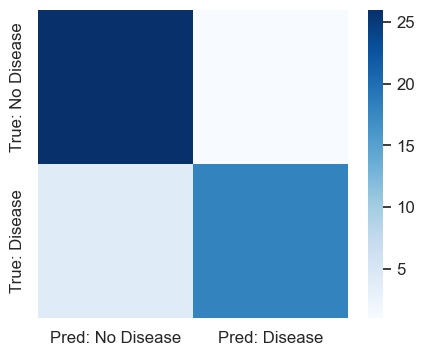


Error breakdown:
error_type
TN    26
TP    18
FN     4
FP     1
Name: count, dtype: int64


In [4]:
print('Classification Report in Validation Set:')
print(classification_report(y_val, y_pred_val, target_names=['No Disease', 'Disease']))

cm = confusion_matrix(y_val, y_pred_val)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: No Disease', 'Pred: Disease'],
            yticklabels=['True: No Disease', 'True: Disease'])
plt.suptitle('')   
plt.savefig('../figures/confusion_matrix.png', bbox_inches='tight')
plt.show()

# Label each validation sample
y_true_arr = y_val.values
error_labels = []
for yt, yp in zip(y_true_arr, y_pred_val):
    if yt == 1 and yp == 1: error_labels.append('TP')
    elif yt == 0 and yp == 0: error_labels.append('TN')
    elif yt == 0 and yp == 1: error_labels.append('FP')
    else: error_labels.append('FN')

val_df = X_val.copy().reset_index(drop=True)
val_df['true_label']   = y_true_arr
val_df['pred_label']   = y_pred_val
val_df['pred_prob']    = y_prob_val
val_df['error_type']   = error_labels

print(f'\nError breakdown:')
print(val_df['error_type'].value_counts())

**Comment:** On the validation set, the model achieved strong overall performance with 90% accuracy and balanced F1-scores for both classes, while identifying most no-disease cases, with only 1 false positive, but missed 4 disease cases, resulting in lower recall for the disease class (0.82), a mistake that is clinically important since predicting diseased patients as a healthy one.

## Age Distribution by Error Type

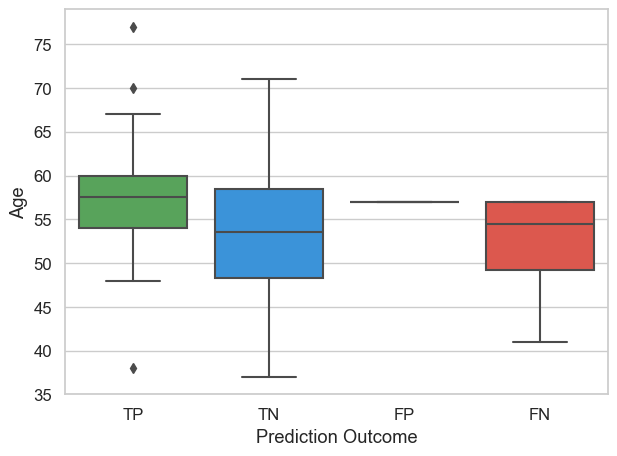

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))

order = ["TP", "TN", "FP", "FN"]
palette = {"TP": "#4CAF50", "TN": "#2196F3", "FP": "#FF9800", "FN": "#F44336"}

val_df_plot = val_df[val_df["error_type"].isin(order)]

sns.boxplot( data=val_df_plot, x="error_type", y="age", order=order, palette=palette, ax=ax)

ax.set_xlabel("Prediction Outcome")
ax.set_ylabel("Age")

plt.savefig("../figures/age_by_error.png", bbox_inches="tight")
plt.show()

**Comment:** Age does not seem to clearly separate correct from incorrect predictions, so model errors are possibly caused by a combination of features rather than age alone.

## Clinical Feature Profiles of FP and FN

,age,thalach,oldpeak,ca,chol,trestbps
error_type,,,,,,
FN,54.5,162.0,0.00,1.0,231.0,121.0
FP,57.0,168.0,0.00,0.0,207.0,132.0
TN,53.5,162.0,0.00,0.0,251.5,130.0
TP,57.5,136.0,1.35,1.0,272.0,131.0


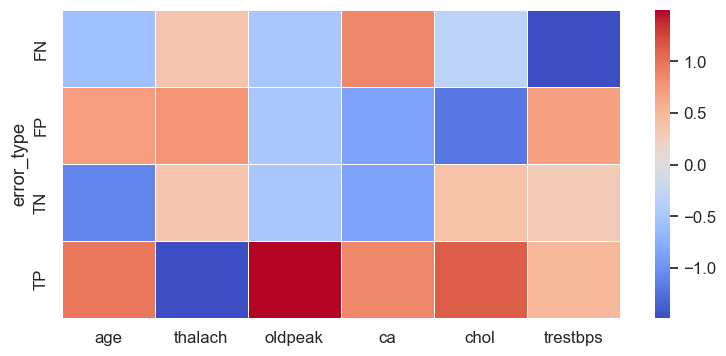

In [13]:
clinical_features = ['age', 'thalach', 'oldpeak', 'ca', 'chol', 'trestbps']

profile = val_df.groupby('error_type')[clinical_features].median()
display(profile)

# Heatmap of normalised feature profiles
profile_norm = (profile - profile.mean()) / (profile.std() + 1e-8)
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(profile_norm, annot=False, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)

plt.savefig('../figures/fp_fn_feature_profiles.png', bbox_inches='tight')
plt.show()

**Comment:** 
- TP cases show higher medians of `chol`, `oldpeak`, and `ca`, together with lower `thalach`, which makes them easier for the model to identify as heart disease. 
- FN show lower `chol` and `oldpeak` and higher `thalach`, making them look less clearly pathological and therefore more likely to be missed by the model.

## SHAP Values on Validation Set

In [14]:
import shap


preprocessor_err = error_pipeline.named_steps["preprocessor"]
clf_err = error_pipeline.named_steps["clf"]
X_val_pp = preprocessor_err.transform(X_val.reset_index(drop=True))
feat_names = preprocessor_err.get_feature_names_out()

X_val_pp_df = pd.DataFrame( X_val_pp, columns=feat_names)

# Winner model -->LDA --> SHAP LinearExplainer
explainer_err = shap.LinearExplainer(clf_err, X_val_pp_df)
shap_vals_err = explainer_err.shap_values(X_val_pp_df)


shap_df = pd.DataFrame(shap_vals_err, columns=feat_names)
shap_df["error_type"] = error_labels

print(f"SHAP shape: {shap_vals_err.shape}")
print(f"Validation preprocessed shape: {X_val_pp_df.shape}")

SHAP shape: (49, 20)
Validation preprocessed shape: (49, 20)


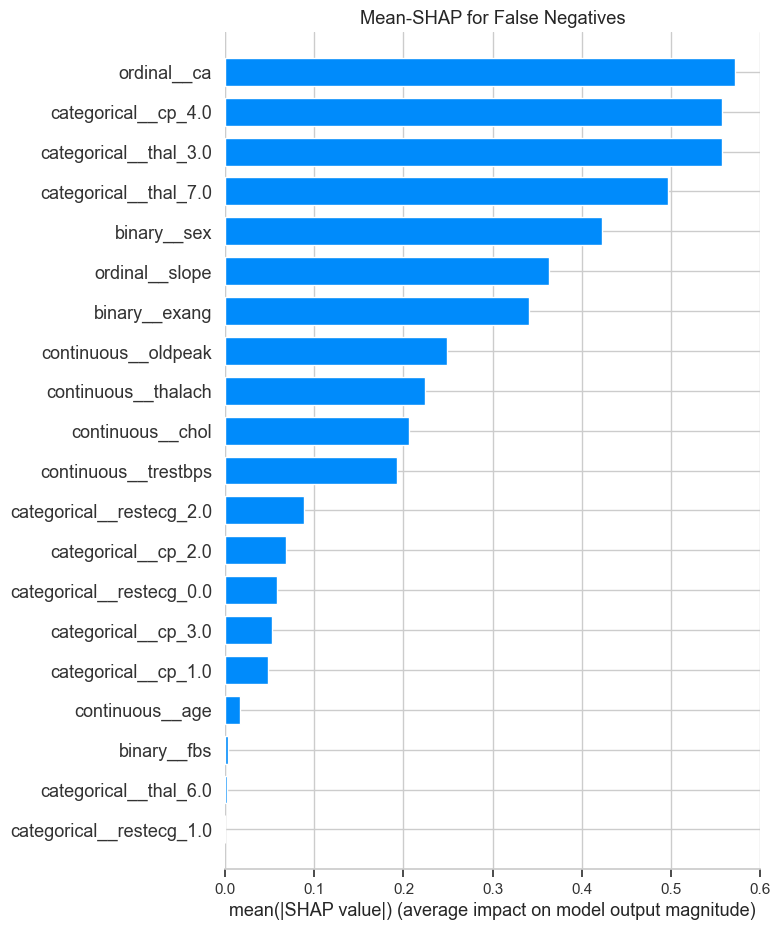

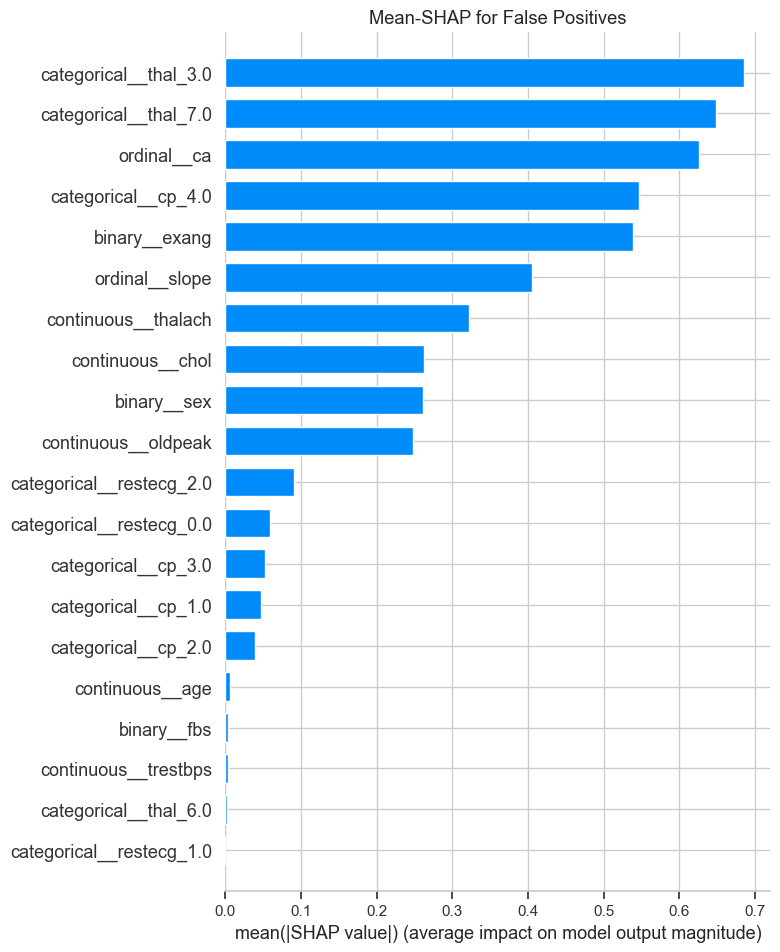

In [17]:
# SHAP bar plots for false negatives and false positives 

fn_mask = np.array(error_labels) == "FN"
fp_mask = np.array(error_labels) == "FP"

if fn_mask.any():
    shap.summary_plot(
        shap_vals_err[fn_mask],
        X_val_pp_df.loc[fn_mask],
        plot_type="bar",
        show=False
    )
    plt.title("Mean-SHAP for False Negatives")
    plt.tight_layout()
    plt.savefig("../figures/shap_false_negatives.png", bbox_inches="tight", dpi=150)
    plt.show()

if fp_mask.any():
    shap.summary_plot(
        shap_vals_err[fp_mask],
        X_val_pp_df.loc[fp_mask],
        plot_type="bar",
        show=False
    )
    
    plt.title("Mean-SHAP for False Positives")
    plt.savefig("../figures/shap_false_positives.png", bbox_inches="tight", dpi=150)
    plt.show()

**Comment:** For both FP and FN, the largest mean SHAP contributions mainly come from `ca`, `thal`, `cp`, meaning that misclassifications are mostly driven by the same clinically important features that dominate the overall model predictions.

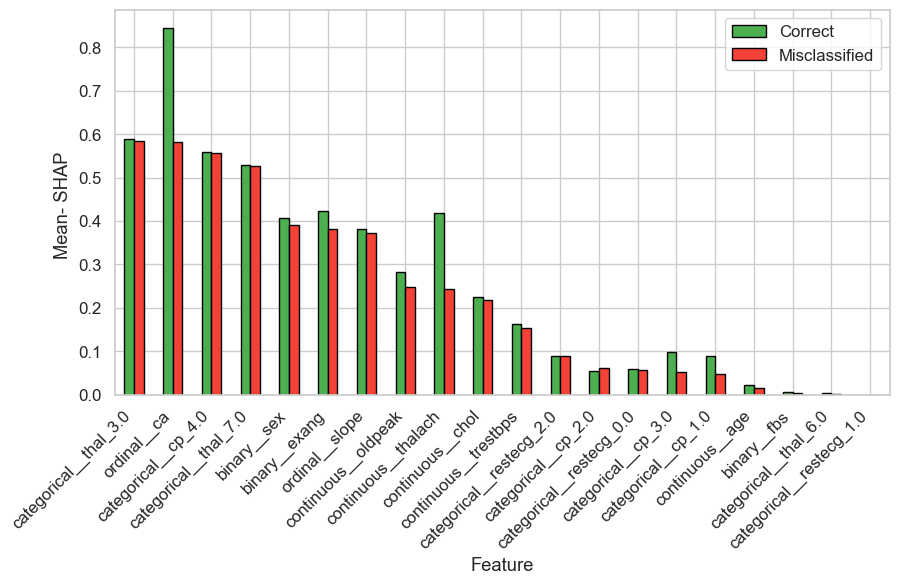

In [24]:
# Compare mean-SHAP between correctly and incorrectly classified patients
correct_mask = np.array([e in ['TP', 'TN'] for e in error_labels])
error_mask   = ~correct_mask

mean_shap_correct = np.abs(shap_vals_err[correct_mask]).mean(axis=0)
mean_shap_error   = np.abs(shap_vals_err[error_mask]).mean(axis=0)

shap_compare_df = pd.DataFrame({
    'Feature':   feat_names,
    'Correct':   mean_shap_correct,
    'Misclassified': mean_shap_error,
}).set_index('Feature').sort_values('Misclassified', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
shap_compare_df.plot(kind='bar', ax=ax, color=['#4CAF50', '#F44336'], edgecolor='black')

ax.set_ylabel('Mean- SHAP ')
plt.xticks(rotation=45, ha='right')

plt.savefig('../figures/shap_correct_vs_error.png', bbox_inches='tight')
plt.show()

**Comment:** Dominance of `ca`, `thal`, and `cp` is intepreted in both groups which confirms these as the model's primary decision drivers, while larger gaps between green and red bars indicate features where misclassified patients showed atypical SHAP contributions.

## Summary

In [22]:
n_fp = sum(1 for e in error_labels if e == 'FP')
n_fn = sum(1 for e in error_labels if e == 'FN')
n_total_val = len(error_labels)

fn_age_median = val_df[val_df['error_type'] == 'FN']['age'].median()
fp_age_median = val_df[val_df['error_type'] == 'FP']['age'].median()

print(f"""
Model: {WINNER} | Validation set: {n_total_val} patients
  - False Negatives: {n_fn} patients ({n_fn/n_total_val*100:.1f}%)
    - Median age: {fn_age_median:.0f} years
  - False Positives: {n_fp} patients ({n_fp/n_total_val*100:.1f}%)
     - Median age: {fp_age_median:.0f} years
""") 


Model: LDA | Validation set: 49 patients
  - False Negatives: 4 patients (8.2%)
    - Median age: 54 years
  - False Positives: 1 patients (2.0%)
     - Median age: 57 years

